Adding physical features 

# Load Data

In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pandas.plotting import register_matplotlib_converters
from utils.data_loader import load_parquet
from sklearn.model_selection import TimeSeriesSplit, BaseCrossValidator
import numpy as np

# Load only specific columns needed for analysis
columns_needed = ['time', 'orbital_decay', '|avg B|', 'F10.7 (LASP)']

GFOC_data = load_parquet(columns=columns_needed)
print(GFOC_data.head())

✅ Successfully loaded data with shape: (3157920, 4)
                 time  orbital_decay   |avg B|  F10.7 (LASP)
0 2023-01-01 00:00:00        16.6730  5.630000         153.0
1 2023-01-01 00:00:20        16.6730  5.633333         153.0
2 2023-01-01 00:00:40        16.6735  5.636667         153.0
3 2023-01-01 00:01:00        16.6740  5.640000         153.0
4 2023-01-01 00:01:20        16.6740  5.633333         153.0


# 1. Select a subset

In [2]:
from utils.plot_loader import create_subset
# =========================== Input ===================================
start_date = '2024-08-01 00:00:00'
end_date = '2024-10-15 00:00:00'
# =====================================================================

subset = create_subset(GFOC_data, start_date, end_date, resample_rate='20s')

dt_seconds = (subset.index[1] - subset.index[0]).total_seconds()
subset['od_daily_mean'] = subset['orbital_decay'].rolling('1D').mean()

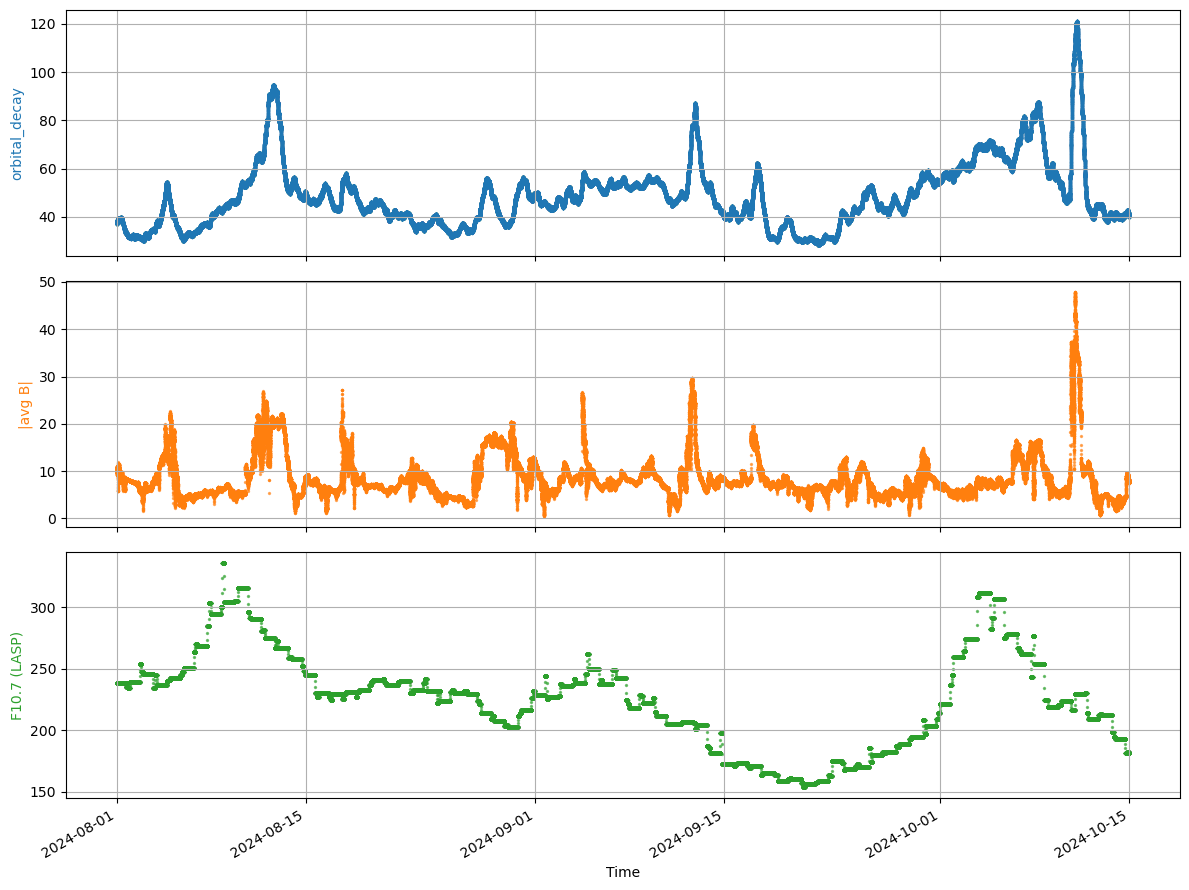

In [3]:
# plot all features from columns_needed
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].scatter(subset.index, subset['orbital_decay'], s=2, c='C0', alpha=0.6)
axes[0].set_ylabel('orbital_decay', color='C0')
axes[0].grid(True)

axes[1].scatter(subset.index, subset['|avg B|'], s=2, c='C1', alpha=0.6)
axes[1].set_ylabel('|avg B|', color='C1')
axes[1].grid(True)

axes[2].scatter(subset.index, subset['F10.7 (LASP)'], s=2, c='C2', alpha=0.6)
axes[2].set_ylabel('F10.7 (LASP)', color='C2')
axes[2].set_xlabel('Time')
axes[2].grid(True)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# 2. Prepare Data

## 2.1 Compute the orbital phase

In [4]:
from numpy.polynomial import Polynomial

p_list = [1.06605722e+02, -7.21846851e-09]
p = Polynomial(p_list)

orbital_period = p(subset.index.astype(np.int64) / 1e9) * 60 # seconds

# cumulative orbital cycles over time
cycles = np.cumsum(1 / orbital_period) * dt_seconds   # because your sampling is every 20s

# phase angle
subset["phase"] = (2 * np.pi * cycles) % (2 * np.pi)

subset["sin_phase"] = np.sin(subset.phase)
subset["cos_phase"] = np.cos(subset.phase)

In [5]:
from statsmodels.tsa.seasonal import STL

# assume regular sampling and compute period in samples:
mean_period_s = np.nanmedian(orbital_period)  # seconds per cycle
period_samples = int(round(mean_period_s / dt_seconds))
seasonal = 20 * period_samples + (20 * period_samples % 2 == 0) # Ensure odd
low_pass_jump = seasonal_jump = int(0.15 * (period_samples + 1))
trend_jump = int(0.15 * 1.5 * (period_samples + 1))

# stl = STL(subset["orbital_decay"], period=period_samples, robust=True)
stl = STL(
    subset["orbital_decay"],
    period=period_samples,
    seasonal=seasonal,
    seasonal_jump=seasonal_jump,
    trend_jump=trend_jump,
    low_pass_jump=low_pass_jump,
)
res = stl.fit()
subset["osc_stl"] = res.seasonal
subset["trend_stl"] = res.trend
subset["resid_stl"] = res.resid

# set variables
subset["oscillation"] = subset["osc_stl"] + subset["resid_stl"]
subset["trend"] = subset["trend_stl"]

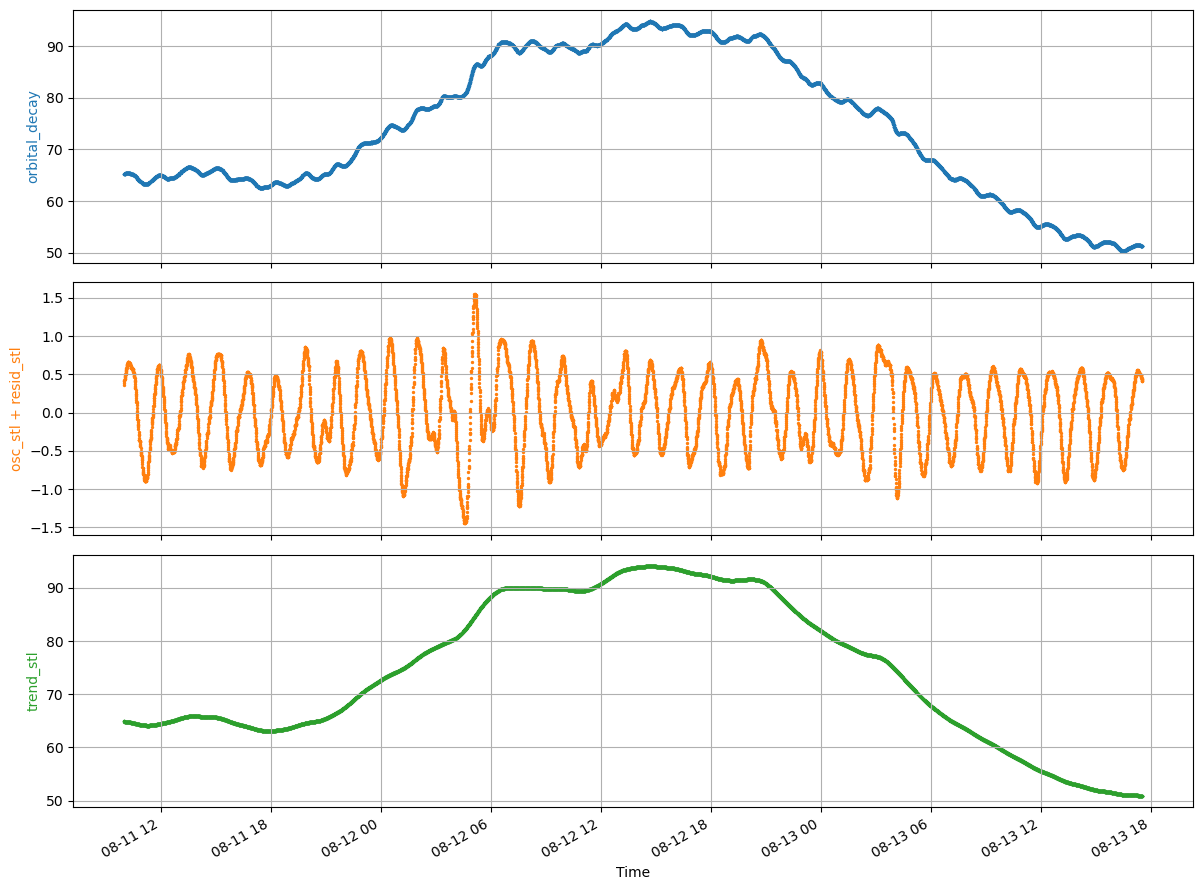

In [6]:

plot_subset = subset.iloc[45000:55000]

# plot all features from columns_needed
fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

axes[0].scatter(plot_subset.index, plot_subset['orbital_decay'], s=2, c='C0')
axes[0].set_ylabel('orbital_decay', color='C0')
axes[0].grid(True)

axes[1].scatter(plot_subset.index, plot_subset['osc_stl'] + plot_subset['resid_stl'], s=2, c='C1')
axes[1].set_ylabel('osc_stl + resid_stl', color='C1')
axes[1].grid(True)

axes[2].scatter(plot_subset.index, plot_subset['trend_stl'], s=2, c='C2')
# axes[2].plot(plot_subset.index, plot_subset['trend_stl'], c='C2', ls = '--', alpha=0.4)
axes[2].set_ylabel('trend_stl', color='C2')
axes[2].set_xlabel('Time')
axes[2].grid(True)

fig.autofmt_xdate()
plt.tight_layout()
plt.show()

# 3 Multioutput Model


In [7]:
def make_lags(df, lag_config, lead_time=1):
    out = {}

    for col, params in lag_config.items():
        n_lags = params.get('lags', 1)

        for i in n_lags:
            out[f"{col}_lag_{i}"] = df[col].shift(i)

    return pd.DataFrame(out)


def make_multistep_target(ts, steps, stepsize=1):
    return pd.concat(
        {f'y_step_{i * stepsize + 1}': ts.shift(-i * stepsize).iloc[:, 0]
         for i in range(steps//stepsize)},
        axis=1)


In [18]:
from warnings import simplefilter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score

simplefilter("ignore")

# Set Matplotlib defaults
plt.style.use("default")
plt.rc("figure", autolayout=True, figsize=(11, 4))
plt.rc(
    "axes",
    labelweight="bold",
    labelsize="large",
    titleweight="bold",
    titlesize=16,
    titlepad=10,
)
plot_params = dict(
    color="0.75",
    style=".-",
    markeredgecolor="0.25",
    markerfacecolor="0.25",
)
%config InlineBackend.figure_format = 'retina'


def plot_multistep(y, every=1, ax=None, palette_kwargs=None):
    palette_kwargs_ = dict(palette='husl', n_colors=16, desat=None)
    if palette_kwargs is not None:
        palette_kwargs_.update(palette_kwargs)
    palette = sns.color_palette(**palette_kwargs_)
    if ax is None:
        fig, ax = plt.subplots()
    ax.set_prop_cycle(plt.cycler('color', palette))
    for date, preds in y[::every].iterrows():
        preds.index = pd.period_range(start=date, periods=len(preds), freq='60S')
        preds.plot(ax=ax, alpha=0.5)
    return ax

def plot_results(y_train, y_fit, y_test, y_pred):
    # skip each m steps for more efficient plotting
    m = 10
    y_train = y_train[::m]
    y_fit = y_fit[::m]
    y_test = y_test[::m]
    y_pred = y_pred[::m]


    palette = dict(palette='husl', n_colors=64)
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6))
    ax1 = y_train.iloc[:,[0]].plot(**plot_params, ax=ax1)
    ax1 = plot_multistep(y_fit, every=60, ax=ax1, palette_kwargs=palette)
    _ = ax1.legend(['Orbital Decay (train)', 'Forecast'])
    ax1.grid(True)

    # plot complete forecast horizon
    temp = y_test.iloc[:,[-1]].copy()
    temp.index = temp.index + pd.Timedelta(hours=n)  #! may need to manualy need to set timedelta here !!!!!!
    temp2 = y_test.iloc[:,[0]].copy()
    temp.columns = temp2.columns
    y_temp = pd.concat([temp2, temp])
    ax2 = y_temp.plot(**plot_params, ax=ax2)
    ax2 = plot_multistep(y_pred, every=60, ax=ax2, palette_kwargs=palette)
    _ = ax2.legend(['Orbital Decay (test)', 'Forecast'])
    # ax2.vlines('2024-05-10 16:37:00', ymin = 0, ymax = 140, color='red', linestyle='--')
    ax2.grid(True)
    plt.tight_layout()
    plt.show()

def statistics(y_train, y_fit, y_test, y_pred):
    train_rmse = root_mean_squared_error(y_train, y_fit)
    test_rmse = root_mean_squared_error(y_test, y_pred)
    print((f"Train RMSE: {train_rmse:.3}\n" f"Test RMSE: {test_rmse:.3}"))
    train_r2 = r2_score(y_train, y_fit)
    test_r2 = r2_score(y_test, y_pred)
    print((f"Train R2: {train_r2:.3}\n" f"Test R2: {test_r2:.3}"))

    train_rmse_list = []
    test_rmse_list = []
    train_r2_list = []
    test_r2_list = []

    for i in range(len(y_train.columns)):
        train_rmse_list.append(root_mean_squared_error(y_train.iloc[:, i], y_fit.iloc[:, i]))
        test_rmse_list.append(root_mean_squared_error(y_test.iloc[:, i], y_pred.iloc[:, i]))
        train_r2_list.append(r2_score(y_train.iloc[:, i], y_fit.iloc[:, i]))
        test_r2_list.append(r2_score(y_test.iloc[:, i], y_pred.iloc[:, i]))
    fix, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    xtrain = [int(col.split('_')[-1]) for col in y_train.iloc[0].index]
    xtest = [int(col.split('_')[-1]) for col in y_test.iloc[0].index]
    ax[0].plot(xtrain,train_rmse_list, label='Train RMSE')
    ax[0].plot(xtest,test_rmse_list, label='Test RMSE')
    ax[0].set_ylabel('RMSE')
    ax[0].legend()
    ax[0].grid(True)

    ax[1].plot(xtrain, train_r2_list, label='Train R2')
    ax[1].plot(xtest, test_r2_list, label='Test R2')
    ax[1].set_ylabel('R2 Score')
    ax[1].set_xlabel('Forecast Step (20s intervals)')
    ax[1].legend()
    ax[1].grid(True)
    plt.tight_layout()
    plt.show()


## 3.2 Predict the trend

In [9]:
hour = int(60 // (dt_seconds / 60))  # number of samples in one hour
lag_config_trend = {
    "od_daily_mean": {"lags": [24*hour, 7*24*hour]}, # we no not want to
    "|avg B|": {'lags': list(range(1, 3*hour, hour//20)) + list(range(3*hour, 24*hour, hour))},
    "F10.7 (LASP)": {'lags': list(range(1, 24*hour, 6*hour)) + list(range(24*hour, 2*24*hour, 12*hour))}
}

X_trend = make_lags(subset, lag_config_trend)

n = 12  # hours ahead
y_stepsize = int(15 * (60 // dt_seconds))
y_trend = make_multistep_target(subset[['trend']].copy(), steps=int(n * 60 * (60 / dt_seconds)), stepsize=y_stepsize)

# Shifting has created indexes that don't match. Only keep times for
na_mask = X_trend.isna().any(axis=1) | y_trend.isna().any(axis=1)
X_trend = X_trend[~na_mask]
y_trend = y_trend[~na_mask]

# Rename columns to avoid MultiIndex issues
X_trend.columns = ['_'.join(map(str, col)) if isinstance(col, tuple) else str(col) for col in X_trend.columns]

print("Number of input parameters for model:", X_trend.shape[1])
print("Number of output steps for model:", y_trend.shape[1])

Number of input parameters for model: 89
Number of output steps for model: 48


In [10]:
from sklearn.linear_model import Lasso, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Train-test split (chronologically)
X_trend_train, X_trend_test, y_trend_train, y_trend_test = train_test_split(X_trend, y_trend, test_size=0.2, shuffle=False)

scaler = StandardScaler()
X_trend_train_scaled = scaler.fit_transform(X_trend_train)
X_trend_test_scaled = scaler.transform(X_trend_test)

model_trend = LinearRegression() #Lasso(alpha=0.01)
model_trend.fit(X_trend_train_scaled, y_trend_train)

y_trend_fit = pd.DataFrame(model_trend.predict(X_trend_train_scaled), index=X_trend_train.index, columns=y_trend_train.columns)
y_trend_pred = pd.DataFrame(model_trend.predict(X_trend_test_scaled), index=X_trend_test.index, columns=y_trend_test.columns)

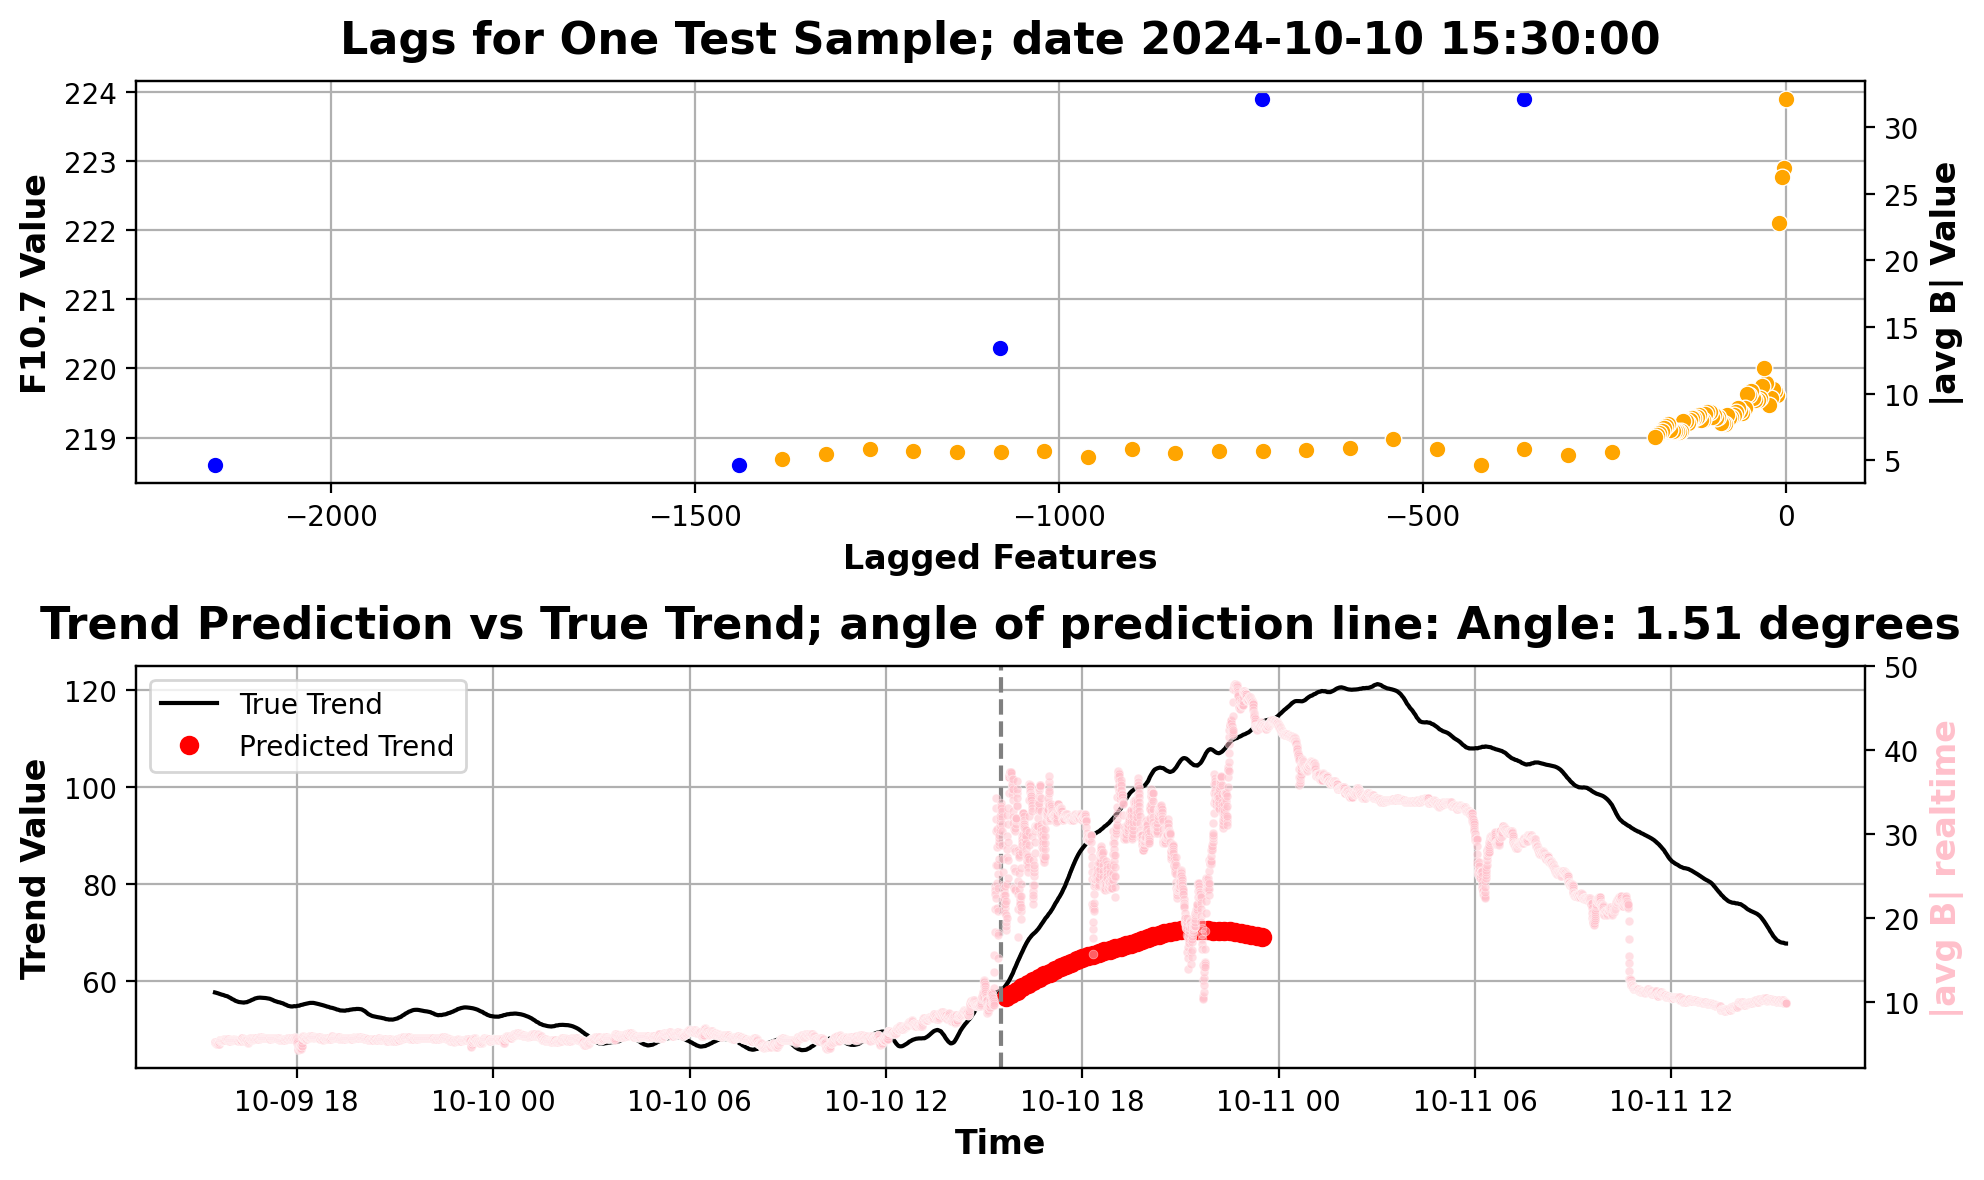

In [ ]:
time = '2024-10-10 15:30:00'
idx = y_trend_test.index.get_loc(time)
sample_test = X_trend_test.iloc[idx]
sample_test_F, sample_test_B = sample_test.filter(like='F10.7'), sample_test.filter(like='|avg B|')
lag_times_F = [-int(col.split('_')[-1]) * dt_seconds / 60 for col in sample_test_F.index]
lag_times_B = [-int(col.split('_')[-1]) * dt_seconds / 60 for col in sample_test_B.index]
sample_test_F.index = lag_times_F
sample_test_B.index = lag_times_B   
sample_test_y = y_trend_test.iloc[idx]
lag_times_y = [int(col.split('_')[-1]) * dt_seconds / 60 for col in sample_test_y.index]

fig, ax = plt.subplots(figsize=(10, 6), nrows=2, ncols=1)
ax = ax.flatten()
sns.scatterplot(x=sample_test_F.index, y=sample_test_F.values, ax=ax[0], color='blue')
ax[0].set_title('Lags for One Test Sample; date '+ str(y_trend_test.iloc[idx].name))
plt.xlabel('Lagged Features')
ax[0].set_ylabel('F10.7 Value')
plt.grid(True)
sns.scatterplot(x=sample_test_B.index, y=sample_test_B.values, ax=ax[0].twinx(), color='orange')
ax[0].set_xlabel('Lagged Features')
plt.ylabel('|avg B| Value')
ax[0].grid(True)  

time_idx = y_trend_test.index[idx]
time_window = (time_idx - pd.Timedelta(hours=24), time_idx + pd.Timedelta(hours=24))
true_trend_window = subset.loc[time_window[0]:time_window[1], 'trend']
pred_trend = y_trend_pred.iloc[idx]
true_decay = subset.loc[time_window[0]:time_window[1], 'orbital_decay']
ax[1].plot(true_decay.index, true_decay.values, label='True Decay', color='black')
pred_times = [time_idx + pd.Timedelta(minutes=10 * (i + 1)) for i in range(len(pred_trend))]
ax[1].plot(pred_times, pred_trend.values, label='Predicted Trend', marker='o', linestyle='None', color='red')

angle = np.arctan2(pred_trend.values[-1] - pred_trend.values[0], (pred_times[-1] - pred_times[0]).total_seconds() / 60)
angle_deg = np.degrees(angle)
angle = f'Angle: {angle_deg:.2f} degrees'
ax[1].set_title(f'Trend Prediction vs True Decay; angle of prediction line: {angle}')
ax[1].set_xlabel('Time')
ax[1].set_ylabel('Trend Value')
ax[1].legend()

# overplot input B as background in ax[1]
bz_window = subset.loc[time_window[0]:time_window[1], '|avg B|']
ax2 = ax[1].twinx()
sns.scatterplot(x=bz_window.index, y=bz_window.values, ax=ax2, color='pink', alpha=0.5, s=10)
ax2.set_ylabel('|avg B| realtime', color='pink')

# add vline at test time index
ax[1].axvline(x=time_idx, color='gray', linestyle='--', label='Prediction Time')
ax[1].grid(True)
plt.tight_layout()

plt.show()  

Train RMSE: 7.04
Test RMSE: 13.2
Train R2: 0.553
Test R2: 0.355


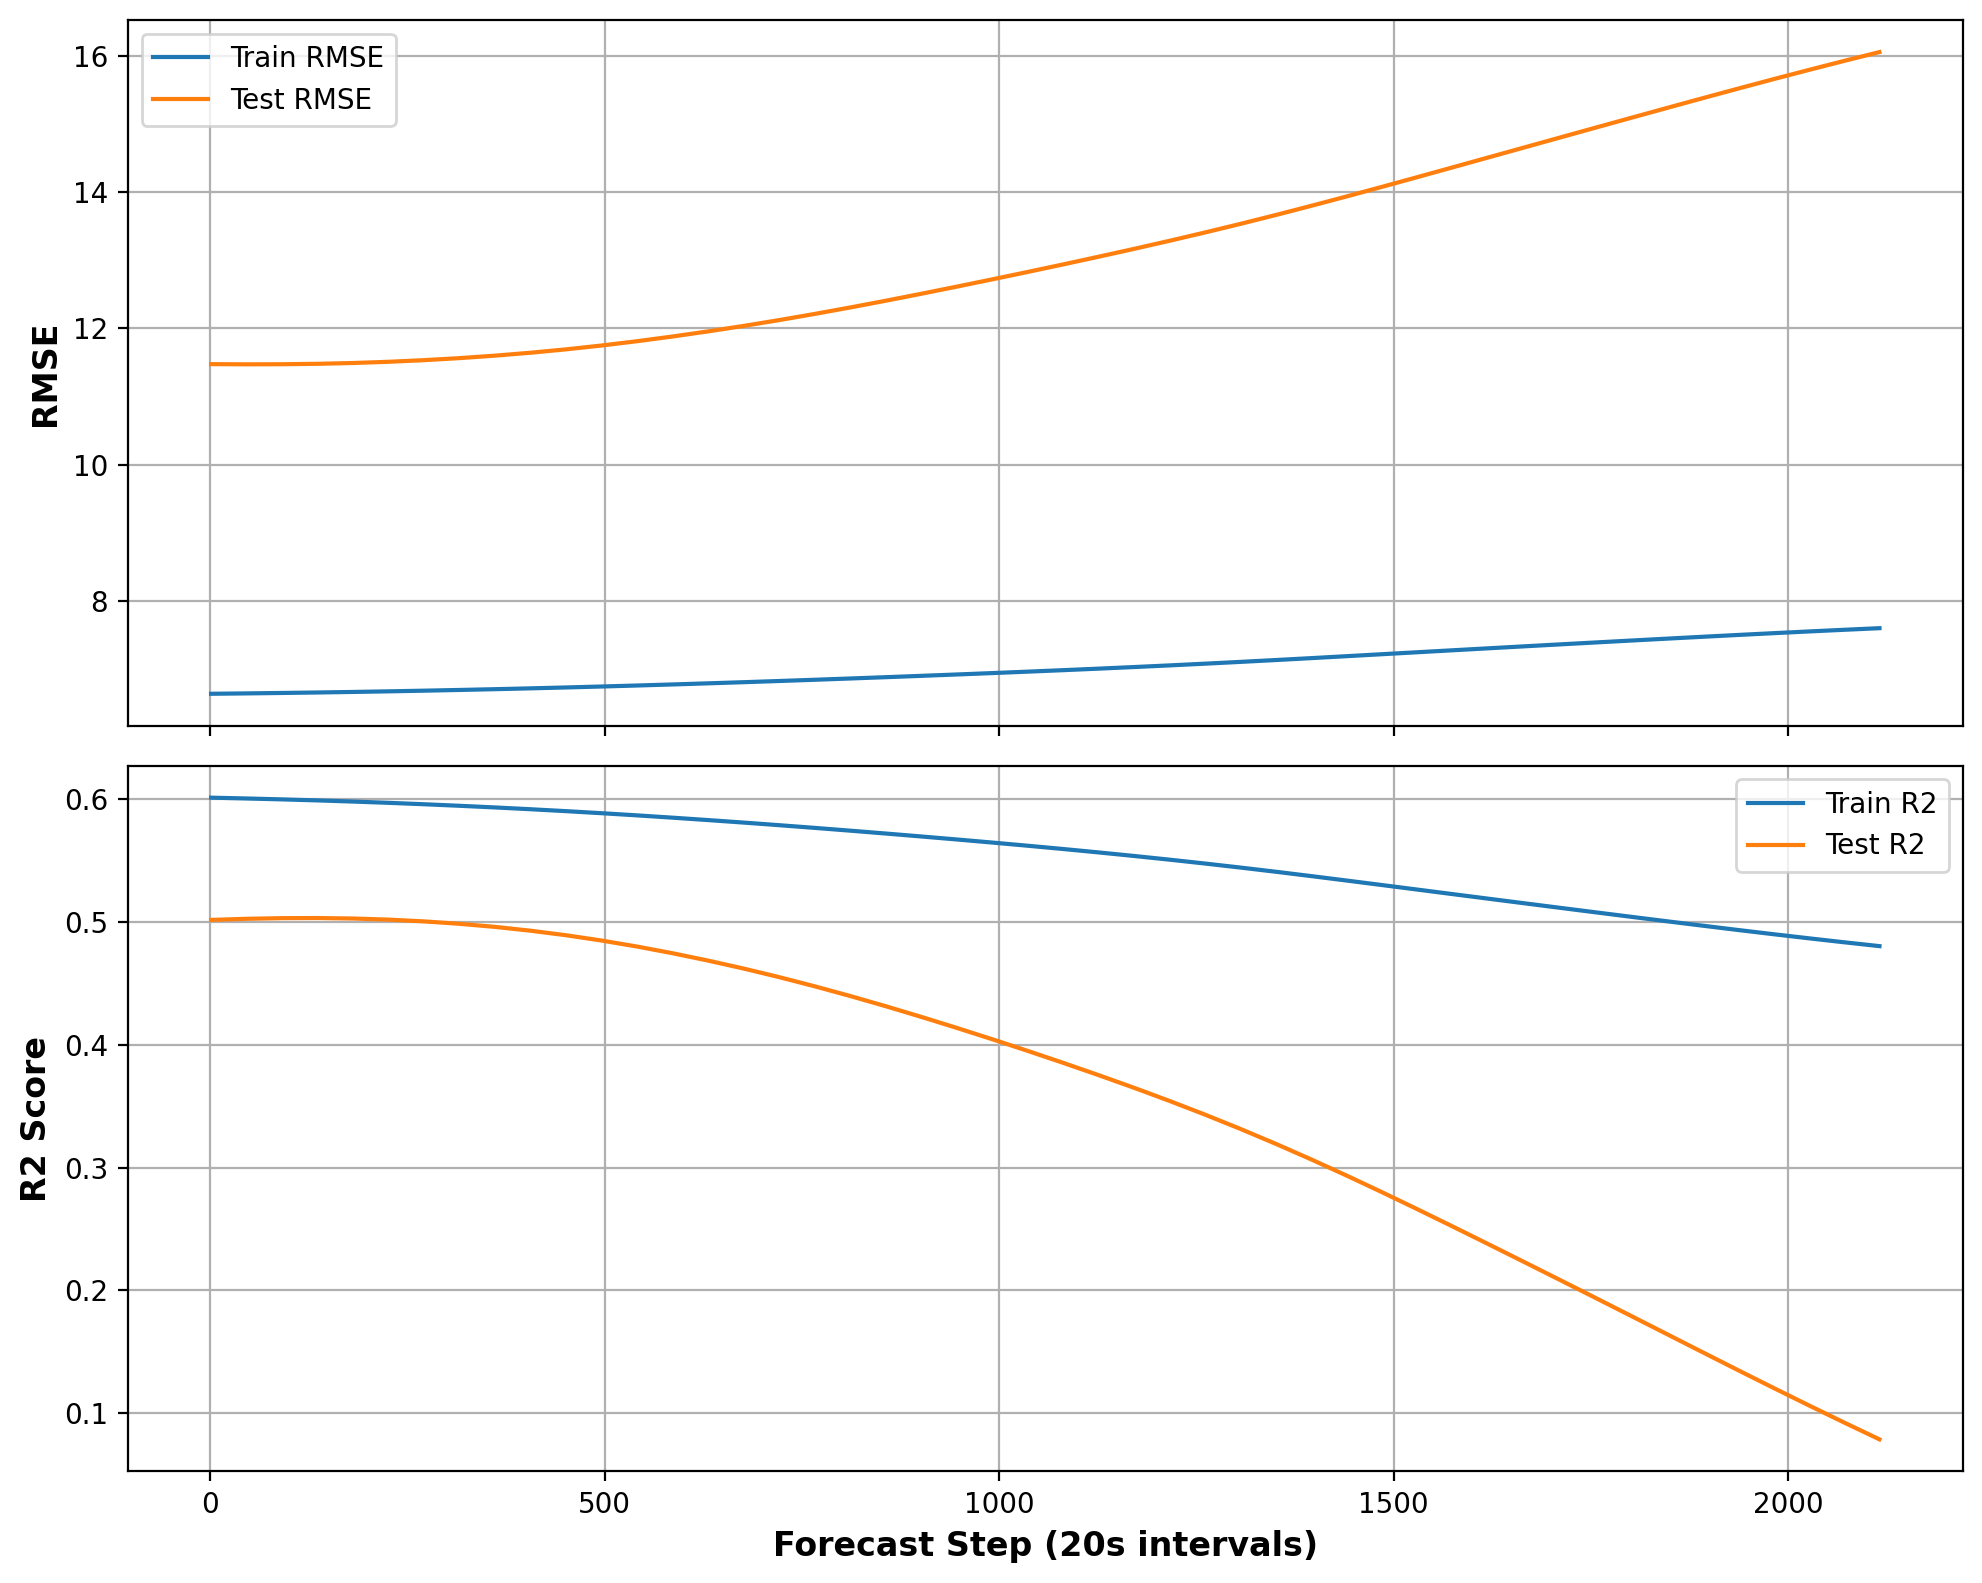

In [19]:
statistics(y_trend_train, y_trend_fit, y_trend_test, y_trend_pred)

In [ ]:
def aggregate_multistep_predictions(y_pred, dt_seconds, error_kind='std'):
    """
    Convert y_pred (shape: origins x horizons, columns like 'y_step_1', 'y_step_46')
    to an aggregated DataFrame indexed by absolute forecast time with columns:
      - mean, std, sem, count, min, max

    Parameters
    ----------
    y_pred : pd.DataFrame
        index = origin timestamps, columns = 'y_step_{k}' for k=1..m
    dt_seconds : int or float
        seconds per step
    error_kind : 'std' or 'sem'
        which error measure to present (std = dispersion, sem = std / sqrt(n))

    Returns
    -------
    agg : pd.DataFrame
        index = absolute forecast timestamps; columns = ['mean','std','sem','count']
    """
    pieces = []
    for col in y_pred.columns:
        # extract integer step from column name; assumes 'y_step_{k}'
        try:
            k = int(col.split('_')[-1])
        except Exception:
            raise ValueError(f"Could not parse step number from column '{col}'")
        # shift the index forward by k steps
        shifted = y_pred[col].copy()
        shifted.index = shifted.index + pd.to_timedelta(k * dt_seconds, unit='s')
        # keep name to help debugging, but all columns will be concatenated
        shifted.name = f'{col}'
        pieces.append(shifted)

    # wide table: index = absolute forecast timestamps, columns = all predictions that land there
    wide = pd.concat(pieces, axis=1)

    # optionally drop completely-empty times
    wide = wide.dropna(how='all')

    # compute aggregates over available predictions at each absolute time
    mean = wide.mean(axis=1, skipna=True)
    std  = wide.std(axis=1, ddof=0, skipna=True)   # population std (ddof=0) — change if needed
    count = wide.count(axis=1)
    sem = std / np.sqrt(count.replace(0, np.nan))
    min_ = wide.min(axis=1, skipna=True)
    max_ = wide.max(axis=1, skipna=True)

    agg = pd.DataFrame({'mean': mean, 'std': std, 'sem': sem, 'count': count, 'min': min_, 'max': max_})

    # choose error column to return in the same df for easy plotting
    agg['error'] = agg['std'] if error_kind == 'std' else agg['sem']

    return agg

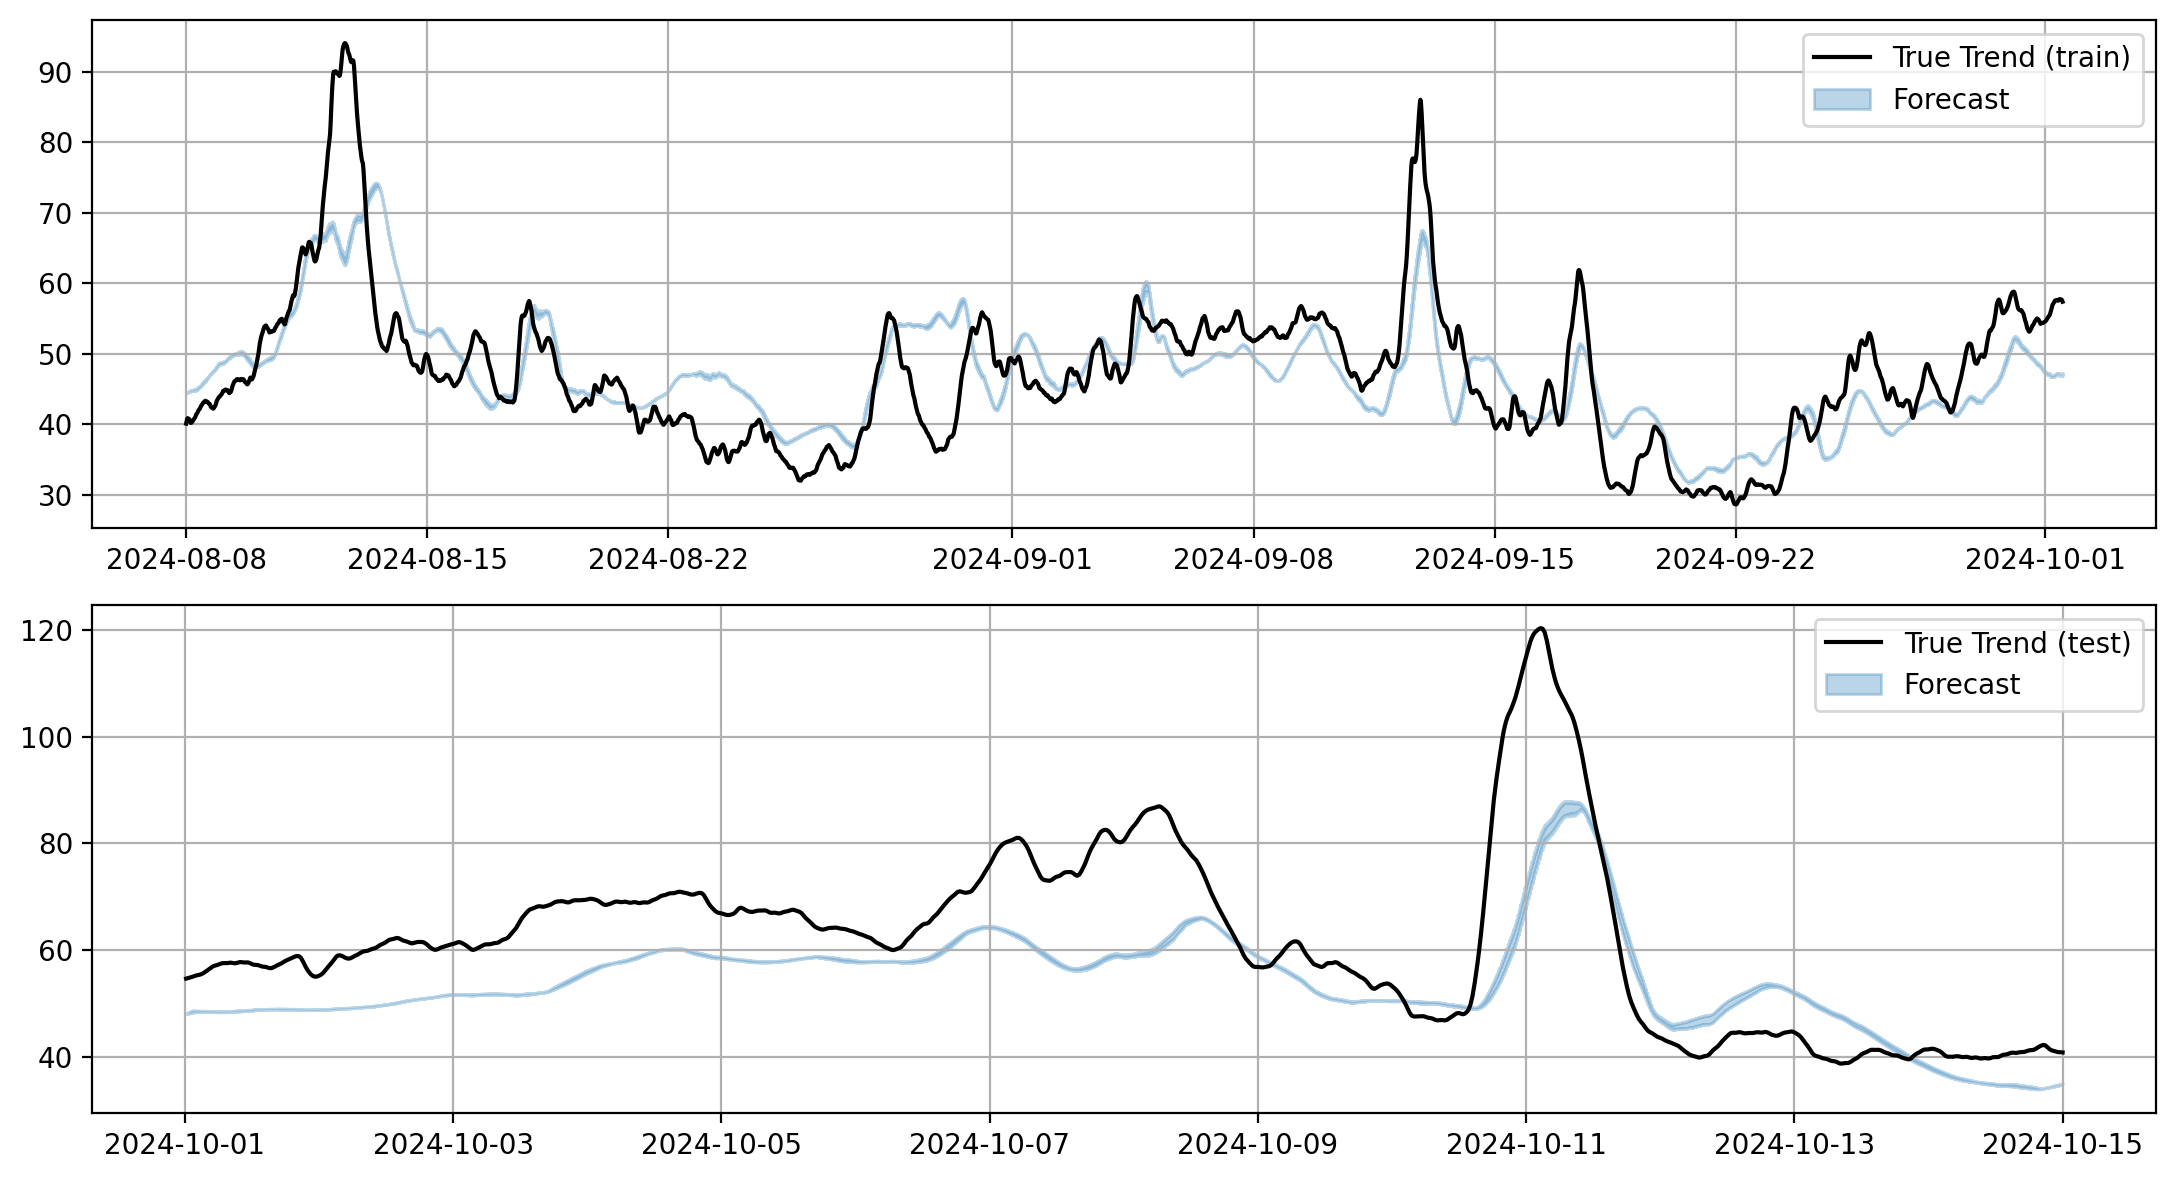

In [14]:
od_train = aggregate_multistep_predictions(y_trend_train, dt_seconds=dt_seconds, error_kind='sem')
od_test = aggregate_multistep_predictions(y_trend_test, dt_seconds=dt_seconds, error_kind='sem')
od_fit = aggregate_multistep_predictions(y_trend_fit, dt_seconds=dt_seconds, error_kind='sem')
od_pred = aggregate_multistep_predictions(y_trend_pred, dt_seconds=dt_seconds, error_kind='sem')

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 6))
ax1.plot(od_train.index, od_train['mean'], color='black')
ax1.fill_between(od_fit.index, od_fit['mean'] - od_fit['error'], od_fit['mean'] + od_fit['error'], color='C0', alpha=0.3)
_ = ax1.legend(['True Trend (train)', 'Forecast'])
ax1.grid(True)

# plot complete forecast horizon
ax2.plot(od_test.index, od_test['mean'], color='black')
ax2.fill_between(od_pred.index, od_pred['mean'] - od_pred['error'], od_pred['mean'] + od_pred['error'], color='C0', alpha=0.3)
_ = ax2.legend(['True Trend (test)', 'Forecast'])
ax2.grid(True)
plt.tight_layout()
plt.show()

## Summary

- works much better with difference, but still not great.